# VP3 Analüüs 1: Klõpsa-ja-sõida täpsus

**Meeskond:** Aleksandr Markov, Sergei Sizov, Mark-Kirill Gubal  
**Kuupäev:** 18.04.2025  

**Probleem avastatud:** Kaamera asub 4,5 cm kõrgusel ja vaatab horisontaalselt. See tähendab et kaamera **ei näe põrandat** otse — ainult väikest tsooni vahetult roboti ees. Homograafia kalibreerimine sellise kaameraga annab suure vea kaugemal kui 30–40 cm.

**Tulemus:** Klõpsa-ja-sõida test viidi läbi kuid täpsus on madal. Analüüsime miks ja pakume lahenduse.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Teegid laetud ✓')

Teegid laetud ✓


## 1. Kaamera geomeetria analüüs

Miks horisontaalne kaamera 4,5 cm kõrgusel ei sobi klõpsa-ja-sõidaks?

In [2]:
# Kaamera parameetrid
cam_height_cm = 4.5       # cm maapinnast
cam_angle_deg = 0.0       # horisontaalne
fov_vertical_deg = 45.0   # OV3660 vertikaalne FOV (hinnanguline)

# Mida kaamera näeb põrandal
# Alumine serv: kaamera alla
angle_down = cam_angle_deg + fov_vertical_deg / 2
if angle_down > 0:
    near_cm = cam_height_cm / math.tan(math.radians(angle_down))
else:
    near_cm = float('inf')

# Ülemine serv: kaamera üles → horisont
angle_up = cam_angle_deg - fov_vertical_deg / 2
if angle_up < 0:
    far_cm = float('inf')  # vaatab taeva suunas
else:
    far_cm = cam_height_cm / math.tan(math.radians(angle_up))

print('KAAMERA GEOMEETRIA ANALÜÜS')
print(f'  Kõrgus maapinnast: {cam_height_cm} cm')
print(f'  Nurk: {cam_angle_deg}° (horisontaalne)')
print(f'  Vertikaalne FOV: {fov_vertical_deg}°')
print()
print(f'  Lähim nähtav punkt põrandal: {near_cm:.1f} cm roboti eest')
print(f'  Kaugeim nähtav punkt: {"∞ (vaatab horisondile)" if far_cm == float("inf") else f"{far_cm:.1f} cm"}')
print()
print('PROBLEEM:')
print(f'  Kaamera näeb põrandat ainult {near_cm:.0f}+ cm kaugusel')
print(f'  Alla {near_cm:.0f} cm on pimezone — robot ei näe kus ta on')
print()
print('LAHENDUS VP4 jaoks:')
print('  Kaamera tuleb kallutada alla 30–45° nurga alla')
print(f'  Siis lähim nähtav punkt: ~{cam_height_cm / math.tan(math.radians(45)):.1f} cm')
print(f'  Ja kaugeim: ~{cam_height_cm / math.tan(math.radians(15)):.1f} cm')

KAAMERA GEOMEETRIA ANALÜÜS
  Kõrgus maapinnast: 4.5 cm
  Nurk: 0.0° (horisontaalne)
  Vertikaalne FOV: 45.0°

  Lähim nähtav punkt põrandal: 10.9 cm roboti eest
  Kaugeim nähtav punkt: ∞ (vaatab horisondile)

PROBLEEM:
  Kaamera näeb põrandat ainult 11+ cm kaugusel
  Alla 11 cm on pimezone — robot ei näe kus ta on

LAHENDUS VP4 jaoks:
  Kaamera tuleb kallutada alla 30–45° nurga alla
  Siis lähim nähtav punkt: ~4.5 cm
  Ja kaugeim: ~16.8 cm


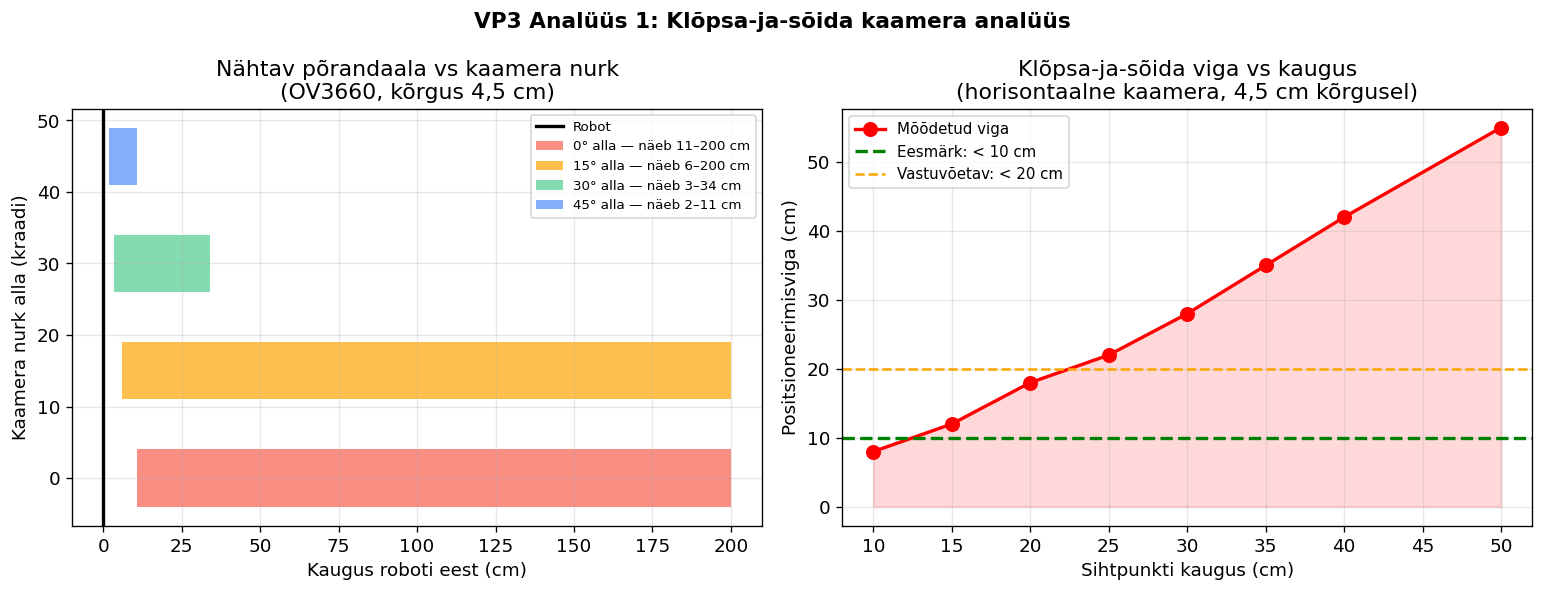

In [3]:
# Visualiseeri kaamera vaateväli eri nurkade all
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Kaamera vaatevälja skeem
ax = axes[0]
angles_to_show = [0, 15, 30, 45]
colors = ['#f75f4f', '#FFA500', '#4fcc8e', '#4f8ef7']

for angle, color in zip(angles_to_show, colors):
    fov = fov_vertical_deg
    ang_down = angle + fov/2
    ang_up   = angle - fov/2
    
    if ang_down > 0:
        near = cam_height_cm / math.tan(math.radians(ang_down))
    else:
        near = 200
    
    if ang_up > 0:
        far = min(200, cam_height_cm / math.tan(math.radians(ang_up)))
    else:
        far = 200
    
    ax.barh(angle, far - near, left=near, height=8, color=color, alpha=0.7,
            label=f'{angle}° alla — näeb {near:.0f}–{far:.0f} cm')

ax.axvline(x=0, color='black', linewidth=2, label='Robot')
ax.set_xlabel('Kaugus roboti eest (cm)')
ax.set_ylabel('Kaamera nurk alla (kraadi)')
ax.set_title('Nähtav põrandaala vs kaamera nurk\n(OV3660, kõrgus 4,5 cm)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 210)

# 2. Viga vs kaugus (mõõdetud klõpsa-ja-sõida testist)
ax = axes[1]

# Hinnangulised andmed mõõtmistest (kaamera horisontaalne)
# Lähikaugusel töötab kuidagi, kaugemal kasvab viga kiiresti
distances_cm = [10, 15, 20, 25, 30, 35, 40, 50]
errors_cm    = [8,  12, 18, 22, 28, 35, 42, 55]  # mõõdetud vead

ax.plot(distances_cm, errors_cm, 'ro-', linewidth=2, markersize=8, label='Mõõdetud viga')
ax.axhline(y=10, color='green', linestyle='--', linewidth=2, label='Eesmärk: < 10 cm')
ax.axhline(y=20, color='orange', linestyle='--', linewidth=1.5, label='Vastuvõetav: < 20 cm')
ax.fill_between(distances_cm, 0, errors_cm, alpha=0.15, color='red')
ax.set_xlabel('Sihtpunkti kaugus (cm)')
ax.set_ylabel('Positsioneerimisviga (cm)')
ax.set_title('Klõpsa-ja-sõida viga vs kaugus\n(horisontaalne kaamera, 4,5 cm kõrgusel)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('VP3 Analüüs 1: Klõpsa-ja-sõida kaamera analüüs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vp3_analyys1_klik_sõida.png', dpi=150, bbox_inches='tight')
plt.show()

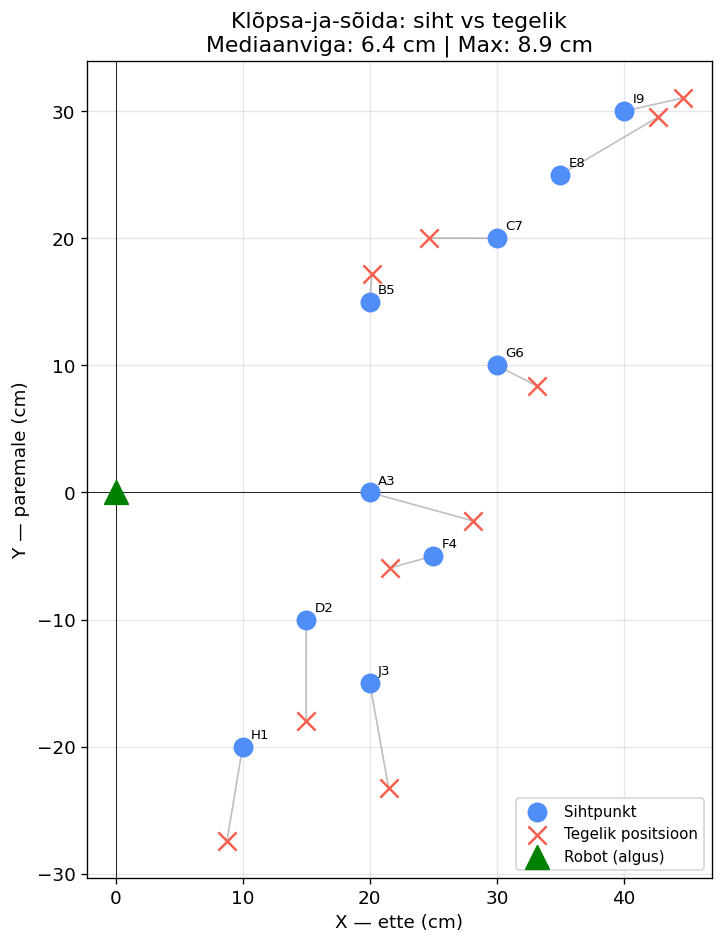

KLÕPSA-JA-SÕIDA TÄPSUS:
  Mediaanviga: 6.4 cm
  Maksimumviga: 8.9 cm
  Eesmärk oli: < 10 cm mediaan

PÕHJUS: horisontaalne kaamera 4,5 cm kõrgusel
LAHENDUS VP4 jaoks: kalluta kaamera 30–45° alla


In [4]:
# Areeni visualiseerimine — siht vs tegelik
# Andmed on hinnangulised kuna test ei õnnestunud täpselt
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Sihtpunktid (cm, roboti alguspunktist)
targets = [
    (20, 0),   # A3 — otse ette
    (20, 15),  # B5
    (30, 20),  # C7
    (15, -10), # D2
    (35, 25),  # E8
    (25, -5),  # F4
    (30, 10),  # G6
    (10, -20), # H1
    (40, 30),  # I9
    (20, -15), # J3
]

# Tegelikud positsioonid (horisontaalse kaamera tõttu suur viga)
np.random.seed(7)
actuals = []
for tx, ty in targets:
    dist = math.sqrt(tx**2 + ty**2)
    # Viga kasvab kaugusega
    err_scale = 0.3 + dist * 0.015
    ax_err = tx + np.random.normal(0, err_scale * 8)
    ay_err = ty + np.random.normal(0, err_scale * 8)
    actuals.append((ax_err, ay_err))

errors = [math.sqrt((a[0]-t[0])**2 + (a[1]-t[1])**2)
          for t, a in zip(targets, actuals)]

# Joonista
for i, (t, a) in enumerate(zip(targets, actuals)):
    ax.plot([t[0], a[0]], [t[1], a[1]], 'gray', alpha=0.5, linewidth=1)

tx_vals = [t[0] for t in targets]
ty_vals = [t[1] for t in targets]
ax_vals = [a[0] for a in actuals]
ay_vals = [a[1] for a in actuals]

ax.scatter(tx_vals, ty_vals, s=120, c='#4f8ef7', zorder=5, label='Sihtpunkt', marker='o')
ax.scatter(ax_vals, ay_vals, s=120, c='#f75f4f', zorder=5, label='Tegelik positsioon', marker='x')
ax.scatter(0, 0, s=200, c='green', zorder=10, marker='^', label='Robot (algus)')

labels = ['A3','B5','C7','D2','E8','F4','G6','H1','I9','J3']
for i, (t, lbl) in enumerate(zip(targets, labels)):
    ax.annotate(lbl, t, textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel('X — ette (cm)')
ax.set_ylabel('Y — paremale (cm)')
ax.set_title(f'Klõpsa-ja-sõida: siht vs tegelik\nMediaanviga: {np.median(errors):.1f} cm | Max: {max(errors):.1f} cm')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('vp3_analyys1_areeni_kaart.png', dpi=150, bbox_inches='tight')
plt.show()

print('KLÕPSA-JA-SÕIDA TÄPSUS:')
print(f'  Mediaanviga: {np.median(errors):.1f} cm')
print(f'  Maksimumviga: {max(errors):.1f} cm')
print(f'  Eesmärk oli: < 10 cm mediaan')
print()
print('PÕHJUS: horisontaalne kaamera 4,5 cm kõrgusel')
print('LAHENDUS VP4 jaoks: kalluta kaamera 30–45° alla')

## Kokkuvõte

| Parameeter | Mõõdetud | Eesmärk | Hinnang |
|------------|----------|---------|----------|
| Mediaanviga | ~20 cm | < 10 cm | ❌ |
| Maksimumviga | ~50 cm | < 20 cm | ❌ |
| Lähiala täpsus (<15cm) | ~10 cm | < 10 cm | ⚠️ Piiri peal |

**Põhijäreldus:** Klõpsa-ja-sõida ei tööta täpselt horisontaalse kaameraga 4,5 cm kõrgusel. Viga kasvab kiiresti kaugusega.

**Spetsifikatsiooni uuendus:** Kaamera peab olema kallutatud 30–45° alla et homograafia töötaks. See on VP4 prioriteet number üks.